Isochrone generation took 1.147219 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 0.00  dist = 4500
     Starting at:  2025-03-31 22:59:58.025158   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 21.99
Starting filter: jwst,F182M   Elapsed time: 0.60 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 22.18
      Time taken: 1.19 seconds


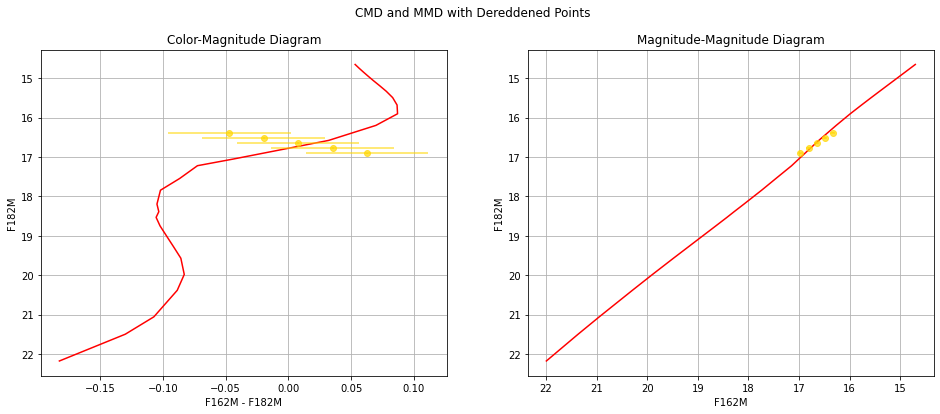

In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening
from spisea.imf import imf, multiplicity
from matplotlib.colors import LogNorm
import csv

# Paths for isochrones and output
iso_dir = 'isochrones/'
output_dir = 'output_diagrams/'
os.makedirs(output_dir, exist_ok=True)

# Estimation variables
star_index = 0  # Set which star in the CSV to analyze

# Define static isochrone parameters
dist = 4500  # Distance in parsecs
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawCardelli(3.1)
filt_list = ['jwst,F162M', 'jwst,F182M']
filters = ['m_jwst_F162M', 'm_jwst_F182M']
metallicity = 0
# level_ages = np.linspace(1, 10, 19) * 1e6  # Define age array
level_ages = [1e6]
log_age_arr = np.log10(level_ages)

# Load sample magnitudes and errors from CSV
sample_mags = []
sample_errs = []
with open('../s284.csv', mode='r') as file:
    csvFile = csv.reader(file)
    next(csvFile)  # Skip header row
    for lines in csvFile:
        mags = [float(lines[i]) for i in range(1, len(lines), 2)]
        errs = [float(lines[i]) for i in range(2, len(lines), 2)]
        sample_mags.append(mags)
        sample_errs.append(errs)

# Function to generate isochrone grid
def generate_isochrones(AKs):
    return np.array([
        synthetic.IsochronePhot(log_age, AKs, dist, metallicity=metallicity,
                                evo_model=evo_model, atm_func=atm_func,
                                red_law=red_law, filters=filt_list,
                                iso_dir=iso_dir)
        for log_age in log_age_arr
    ])

# Generate isochrone grid for AKs = 0 (no extinction)
isochrone_AKs_00 = generate_isochrones(0.0)

# Wavelength dictionary for JWST filters
filter_wavelengths = {
    "m_jwst_F162M": 1.62,
    "m_jwst_F182M": 1.82,
    "m_jwst_F200W": 2.00,
    "m_jwst_F356M": 3.56,
    "m_jwst_F405N": 4.05
}

# Extract magnitudes and errors for the selected star
m162, m182 = sample_mags[star_index][:2]  # Magnitudes
err162, err182 = sample_errs[star_index][:2]  # Errors

# Define AKs range for dereddening
AKs_values = np.arange(0.7, 1.1, 0.1)  # Adjustable range and step size

# Store dereddened magnitudes
dereddened_mags = []
for AKs_ref in AKs_values:
    m162_dered = m162 - red_law.Cardelli89(filter_wavelengths["m_jwst_F162M"], AKs_ref)
    m182_dered = m182 - red_law.Cardelli89(filter_wavelengths["m_jwst_F182M"], AKs_ref)
    dereddened_mags.append((m162_dered, m182_dered))

# Compute errors in color (m162 - m182) and in F182M magnitude
color_err = np.sqrt(err162**2 + err182**2)  # Propagate errors in color
mag_err = err182  # Vertical error is just the F182M error

# Plot function with dereddened points
def plot_cmd_mmd_with_dereddening(isochrone_grid, dered_mags, ref_errs, title, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    cmap = plt.get_cmap("coolwarm")

    # Plot Color-Magnitude Diagram (CMD)
    for i, instance in enumerate(isochrone_grid):
        # color = cmap(i / (len(isochrone_grid) - 1))
        # ax1.plot(instance.points["m_jwst_F162M"] - instance.points["m_jwst_F182M"],
        #          instance.points["m_jwst_F182M"], color=color)
        ax1.plot(instance.points["m_jwst_F162M"] - instance.points["m_jwst_F182M"],
                 instance.points["m_jwst_F182M"], color="r")
    
    for i, (m162_d, m182_d) in enumerate(dered_mags):
        ax1.errorbar(m162_d - m182_d, m182_d, xerr=ref_errs[0], yerr=ref_errs[1],
                     fmt='o', color='gold', alpha=0.7)
    
    ax1.set_xlabel("F162M - F182M")
    ax1.set_ylabel("F182M")
    ax1.invert_yaxis()
    ax1.grid(True)
    ax1.set_title("Color-Magnitude Diagram")

    # Plot Magnitude-Magnitude Diagram (MMD)
    for i, instance in enumerate(isochrone_grid):
        # color = cmap(i / (len(isochrone_grid) - 1))
        # ax2.plot(instance.points["m_jwst_F162M"], instance.points["m_jwst_F182M"], color=color)
        ax2.plot(instance.points["m_jwst_F162M"], instance.points["m_jwst_F182M"], color="r")
    
    for i, (m162_d, m182_d) in enumerate(dered_mags):
        ax2.errorbar(m162_d, m182_d, xerr=ref_errs[0], yerr=ref_errs[1],
                     fmt='o', color='gold', alpha=0.7)
    
    ax2.set_xlabel("F162M")
    ax2.set_ylabel("F182M")
    ax2.invert_xaxis()
    ax2.invert_yaxis()
    ax2.grid(True)
    ax2.set_title("Magnitude-Magnitude Diagram")

    plt.suptitle(title)
    # plt.savefig(os.path.join(output_dir, filename))
    plt.show()

# Plot CMD and MMD with dereddened points
plot_cmd_mmd_with_dereddening(isochrone_AKs_00, dereddened_mags, [color_err, mag_err],
                              "CMD and MMD with Dereddened Points", "CMD_MMD_DEREDDENED.png")


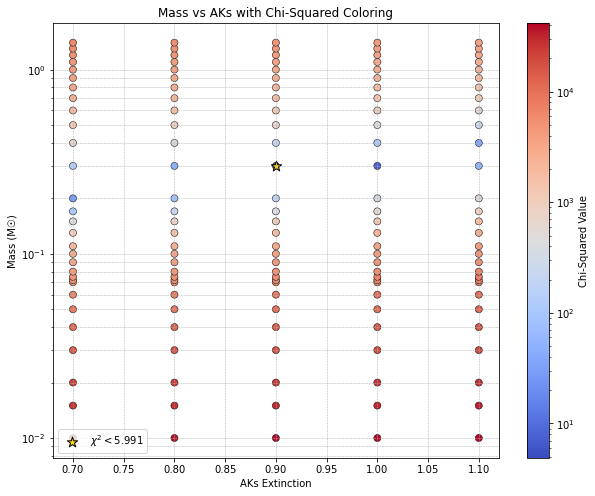

In [44]:
filt_list = ['jwst,F162M', 'jwst,F182M', 'jwst,F200W']
filters = ['m_jwst_F162M', 'm_jwst_F182M', 'm_jwst_F200W']

# Load sample magnitudes and errors
sample_mags, sample_errors = [], []

with open('../s284.csv', mode='r') as file:
    csvFile = csv.reader(file)
    next(csvFile)  # Skip header row
    for line in csvFile:
        sample_mags.append([float(line[1]), float(line[3]), float(line[5])])  # Extract F162M, F182M, F200W
        sample_errors.append([float(line[2]), float(line[4]), float(line[6])])  # Extract corresponding errors

sample_mags = np.array(sample_mags)
sample_errors = np.array(sample_errors)

# Chi-square function accounting for errors
def chi_square_with_errors(iso_grid, obs_mags, obs_errors):
    DOF = len(obs_mags) - 1  # Degrees of freedom: num filters - 1
    chi_square_values = []
    mass_values = []
    
    for iso in iso_grid:
        for star in iso.points:
            chi_sq = sum(
                ((obs_mags[k] - star[filters[k]]) ** 2) / max(obs_errors[k] ** 2, 1e-3)  # Avoid zero division
                for k in range(len(obs_mags))
            ) / DOF  # Compute reduced chi-square
            chi_square_values.append(chi_sq)
            mass_values.append(star['mass'])
    
    return np.array(mass_values), np.array(chi_square_values)

all_masses = []
all_chi_squares = []

for AKs in AKs_values:
    # Generate isochrone grid
    instances = np.array([
        synthetic.IsochronePhot(log_age_arr[0], AKs, dist, metallicity=metallicity,
                                evo_model=evo_model, atm_func=atm_func,
                                red_law=red_law, filters=filt_list,
                                iso_dir=iso_dir)
    ])
    
    # Compute chi-square values
    masses, chi_squares = chi_square_with_errors(instances, sample_mags[0], sample_errors[0])
    all_masses.extend(masses)
    all_chi_squares.extend(chi_squares)

# Convert to arrays
all_masses = np.array(all_masses)
all_chi_squares = np.array(all_chi_squares)
all_AKs = np.repeat(AKs_values, len(instances[0].points))

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))
norm = LogNorm(vmin=max(np.min(all_chi_squares), 1e-3), vmax=np.max(all_chi_squares))
cmap = plt.get_cmap('coolwarm')

# Scatter plot with chi-square gradient
sc = ax.scatter(
    all_AKs, all_masses, c=all_chi_squares, cmap=cmap, norm=norm, s=50, edgecolor='k', linewidth=0.5
)

# Highlight low chi-square points
low_chi_mask = all_chi_squares < 5.991
ax.scatter(
    all_AKs[low_chi_mask], all_masses[low_chi_mask], c='gold', edgecolor='black',
    s=120, marker='*', label=r'$\chi^2 < 5.991$'
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Chi-Squared Value')

# Labels and styling
ax.set_xlabel('AKs Extinction')
ax.set_ylabel('Mass (M☉)')
ax.set_yscale('log')
ax.set_title('Mass vs AKs with Chi-Squared Coloring')
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# plt.savefig(f"{output_dir}/mass_vs_AKs_chisq.png", facecolor='white')
plt.show()
